## LINK DATASET
https://www.kaggle.com/datasets/miadul/brain-tumor-mri-dataset

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("miadul/brain-tumor-mri-dataset")

print("Path to dataset files:", path)

100%|██████████| 236M/236M [00:16<00:00, 15.5MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/miadul/brain-tumor-mri-dataset/versions/1


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications import EfficientNetB0, ConvNeXtSmall
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from collections import Counter
from shutil import copyfile
from sklearn.model_selection import train_test_split
import os
import warnings
warnings.filterwarnings("ignore")

In [ ]:
BATCH_SIZE = 32
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)
INPUT_SHAPE = (IMG_HEIGHT, IMG_WIDTH, 3)
SEED = 42
EPOCHS = 20
LEARNING_RATE = 1e-3
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [ ]:
import shutil

source_path = path
destination_path = "/content/drive/MyDrive/Brain_Tumor_MRI_Images"

shutil.copytree(source_path, destination_path)

'/content/drive/MyDrive/Brain_Tumor_MRI_Images'

In [ ]:
for dirName,_,fileName in os.walk(destination_path):
   print(dirName)

/content/drive/MyDrive/Brain_Tumor_MRI_Images
/content/drive/MyDrive/Brain_Tumor_MRI_Images/brain_tumor_dataset
/content/drive/MyDrive/Brain_Tumor_MRI_Images/brain_tumor_dataset/healthy
/content/drive/MyDrive/Brain_Tumor_MRI_Images/brain_tumor_dataset/glioma
/content/drive/MyDrive/Brain_Tumor_MRI_Images/brain_tumor_dataset/pituitary
/content/drive/MyDrive/Brain_Tumor_MRI_Images/brain_tumor_dataset/meningioma


In [ ]:
base_dir = "/content/Brain_Tumor_MRI_Images"

os.makedirs(os.path.join(base_dir, "pituitary"), exist_ok=True)
os.makedirs(os.path.join(base_dir, "healthy"), exist_ok=True)
os.makedirs(os.path.join(base_dir, "glioma"), exist_ok=True)
os.makedirs(os.path.join(base_dir, "meningioma"), exist_ok=True)

In [ ]:
def move_all_images(SOURCE, DESTINATION):
    files = []

    for filename in os.listdir(SOURCE):
        file_path = os.path.join(SOURCE, filename)

        if os.path.getsize(file_path) > 0:
            files.append(filename)
        else:
            print(filename + " is corrupted, skipping.")

    print(f"Total valid images: {len(files)}")

    for filename in files:
        source_path = os.path.join(SOURCE, filename)
        dest_path = os.path.join(DESTINATION, filename)

        copyfile(source_path, dest_path)

    print("Done copying all images")

In [ ]:
pituitary_SOURCE_DIR = "/content/drive/MyDrive/Brain_Tumor_MRI_Images/brain_tumor_dataset/pituitary/"
healthy_SOURCE_DIR = "/content/drive/MyDrive/Brain_Tumor_MRI_Images/brain_tumor_dataset/healthy/"
glioma_SOURCE_DIR = "/content/drive/MyDrive/Brain_Tumor_MRI_Images/brain_tumor_dataset/glioma/"
meningioma_SOURCE_DIR = "/content/drive/MyDrive/Brain_Tumor_MRI_Images/brain_tumor_dataset/meningioma/"

pituitary_DIR = "/content/Brain_Tumor_MRI_Images/pituitary/"

healthy_DIR = "/content/Brain_Tumor_MRI_Images/healthy/"

glioma_DIR = "/content/Brain_Tumor_MRI_Images/glioma/"

meningioma_DIR = "/content/Brain_Tumor_MRI_Images/meningioma/"

In [ ]:
move_all_images(pituitary_SOURCE_DIR,pituitary_DIR,)
move_all_images(healthy_SOURCE_DIR,healthy_DIR)
move_all_images(glioma_SOURCE_DIR,glioma_DIR)
move_all_images(meningioma_SOURCE_DIR,meningioma_DIR)

Total valid images: 1757
Done copying all images
Total valid images: 2000
Done copying all images
Total valid images: 1621
Done copying all images
Total valid images: 1645
Done copying all images


In [ ]:
import os
import numpy as np
from collections import Counter

BASE_DIR = '/content/Brain_Tumor_MRI_Images'
all_images = []
all_labels = []
class_names = sorted(os.listdir(BASE_DIR))
class_to_idx = {name: idx for idx, name in enumerate(class_names)}

print(f"\nScanning directory: {BASE_DIR}")
print(f"Found {len(class_names)} classes")
print(f"Classes: {class_names}")

for class_name in class_names:
    class_dir = os.path.join(BASE_DIR, class_name)
    if not os.path.isdir(class_dir):
        continue

    for img_name in os.listdir(class_dir):
        if img_name.lower().endswith(('.png', '.jpg', '.jpeg', '.bmp')):
            img_path = os.path.join(class_dir, img_name)
            all_images.append(img_path)
            all_labels.append(class_to_idx[class_name])

all_images = np.array(all_images)
all_labels = np.array(all_labels)

print(f"\nTotal images found: {len(all_images)}")
print(f"Number of classes: {len(class_names)}")
class_counts = Counter(all_labels)
for idx, class_name in enumerate(class_names):
    print(f"  {class_name}: {class_counts[idx]} images")



Scanning directory: /content/Brain_Tumor_MRI_Images
Found 4 classes
Classes: ['glioma', 'healthy', 'meningioma', 'pituitary']

Total images found: 7023
Number of classes: 4
  glioma: 1621 images
  healthy: 2000 images
  meningioma: 1645 images
  pituitary: 1757 images


In [ ]:
train_paths, temp_paths, train_labels, temp_labels = train_test_split(
    all_images,
    all_labels,
    test_size=0.2,
    stratify=all_labels,
    random_state=SEED
)

val_paths, test_paths, val_labels, test_labels = train_test_split(
    temp_paths,
    temp_labels,
    test_size=0.5,
    stratify=temp_labels,
    random_state=SEED
)

In [ ]:
print(f"\nSplit Summary:")
print(f"Train: {len(train_paths)} images ({len(train_paths)/len(all_images)*100:.1f}%)")
print(f"Validation: {len(val_paths)} images ({len(val_paths)/len(all_images)*100:.1f}%)")
print(f"Test: {len(test_paths)} images ({len(test_paths)/len(all_images)*100:.1f}%)")


Split Summary:
Train: 5618 images (80.0%)
Validation: 702 images (10.0%)
Test: 703 images (10.0%)


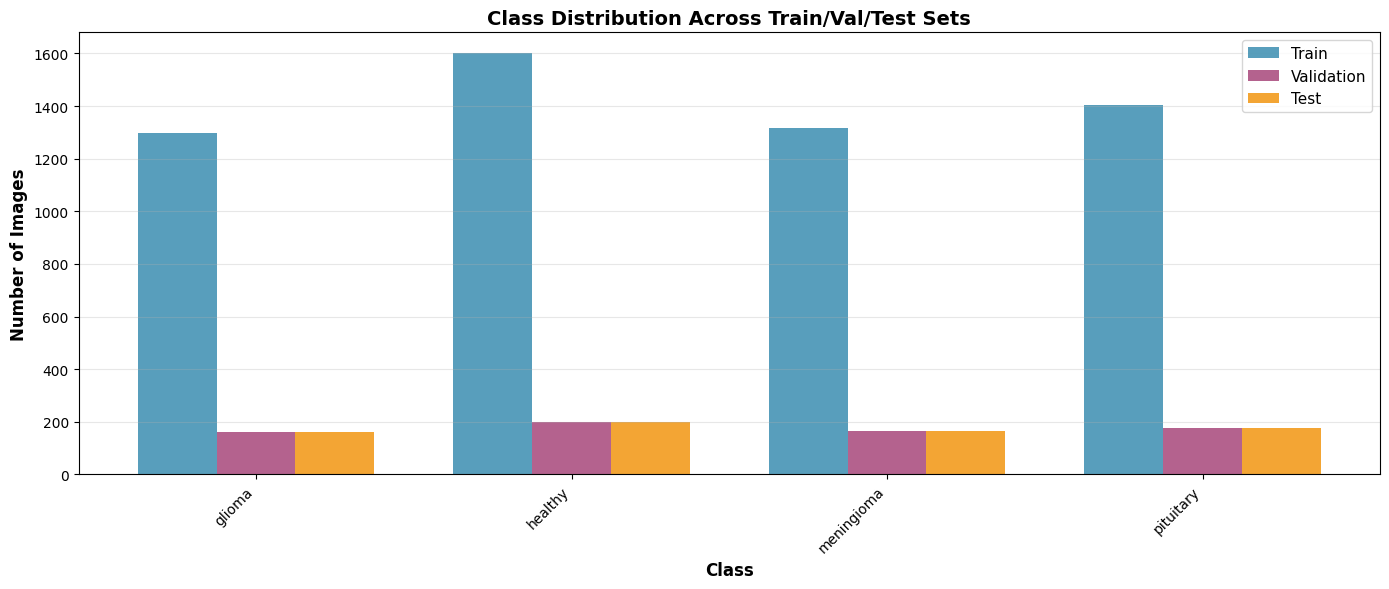

In [ ]:
def plot_class_distribution(train_labels, val_labels, test_labels, class_names):
    """Plot class distribution across splits"""

    train_counts = Counter(train_labels)
    val_counts = Counter(val_labels)
    test_counts = Counter(test_labels)

    # Prepare data for plotting
    x = np.arange(len(class_names))
    width = 0.25

    train_vals = [train_counts[i] for i in range(len(class_names))]
    val_vals = [val_counts[i] for i in range(len(class_names))]
    test_vals = [test_counts[i] for i in range(len(class_names))]

    fig, ax = plt.subplots(figsize=(14, 6))

    ax.bar(x - width, train_vals, width, label='Train', alpha=0.8, color='#2E86AB')
    ax.bar(x, val_vals, width, label='Validation', alpha=0.8, color='#A23B72')
    ax.bar(x + width, test_vals, width, label='Test', alpha=0.8, color='#F18F01')

    ax.set_xlabel('Class', fontsize=12, fontweight='bold')
    ax.set_ylabel('Number of Images', fontsize=12, fontweight='bold')
    ax.set_title('Class Distribution Across Train/Val/Test Sets', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=10)
    ax.legend(fontsize=11)
    ax.grid(axis='y', alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_class_distribution(train_labels, val_labels, test_labels, class_names)


In [ ]:
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomTranslation(0.1, 0.1),
], name="data_augmentation")


In [ ]:
def create_dataset(image_paths, labels, preprocess_fn, augment=False, shuffle=True):

    def load_and_preprocess(path, label):
        img = tf.io.read_file(path)
        img = tf.image.decode_jpeg(img, channels=3)
        img = tf.image.resize(img, IMG_SIZE)
        return img, label

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(load_and_preprocess, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000, seed=SEED)

    dataset = dataset.batch(BATCH_SIZE)

    if augment:
        dataset = dataset.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE
        )

    dataset = dataset.map(
        lambda x, y: (preprocess_fn(x), y),
        num_parallel_calls=tf.data.AUTOTUNE
    )

    return dataset.prefetch(tf.data.AUTOTUNE)


In [ ]:
def preprocess_efficientnet(x):
    return tf.keras.applications.efficientnet.preprocess_input(x)

train_ds_eff = create_dataset(train_paths, train_labels, preprocess_efficientnet, augment=True, shuffle=True)
val_ds_eff = create_dataset(val_paths, val_labels, preprocess_efficientnet, augment=False, shuffle=False)
test_ds_eff = create_dataset(test_paths, test_labels, preprocess_efficientnet, augment=False, shuffle=False)


In [ ]:
def build_efficientnet_model(num_classes):
    base_model = EfficientNetB0(
        include_top=False,
        weights='imagenet',
        input_shape=INPUT_SHAPE,
        pooling='max'
    )

    inputs = base_model.input
    x = base_model.output
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="EfficientNetB0_BrainTumor")

    return model

In [ ]:
num_classes = len(class_names)
model_eff = build_efficientnet_model(num_classes)

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [ ]:
model_eff.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

callbacks_eff = [
    keras.callbacks.EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=3, min_lr=1e-7, verbose=1),
    keras.callbacks.ModelCheckpoint('best_efficientnet_Brain.keras', monitor='val_accuracy', save_best_only=True, verbose=1)
]
history_eff = model_eff.fit(
    train_ds_eff,
    validation_data=val_ds_eff,
    epochs=EPOCHS,
    callbacks=callbacks_eff,
    verbose=1
)

Epoch 1/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 754ms/step - accuracy: 0.7628 - loss: 1.2710
Epoch 1: val_accuracy improved from None to 0.74644, saving model to best_efficientnet_Brain.keras

Epoch 1: finished saving model to best_efficientnet_Brain.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 257s 878ms/step - accuracy: 0.8519 - loss: 0.6634 - val_accuracy: 0.7464 - val_loss: 2.2489 - learning_rate: 0.0010
Epoch 2/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 461ms/step - accuracy: 0.9161 - loss: 0.2379
Epoch 2: val_accuracy improved from 0.74644 to 0.86325, saving model to best_efficientnet_Brain.keras

Epoch 2: finished saving model to best_efficientnet_Brain.keras
176/176 ━━━━━━━━━━━━━━━━━━━━ 87s 474ms/step - accuracy: 0.9315 - loss: 0.1967 - val_accuracy: 0.8632 - val_loss: 0.6613 - learning_rate: 0.0010
Epoch 3/20
176/176 ━━━━━━━━━━━━━━━━━━━━ 0s 451ms/step - accuracy: 0.9430 - loss: 0.1678
Epoch 3: val_accuracy improved from 0.86325 to 0.92450, saving model to best_efficientnet_Brain.keras

Epoch 3: fini

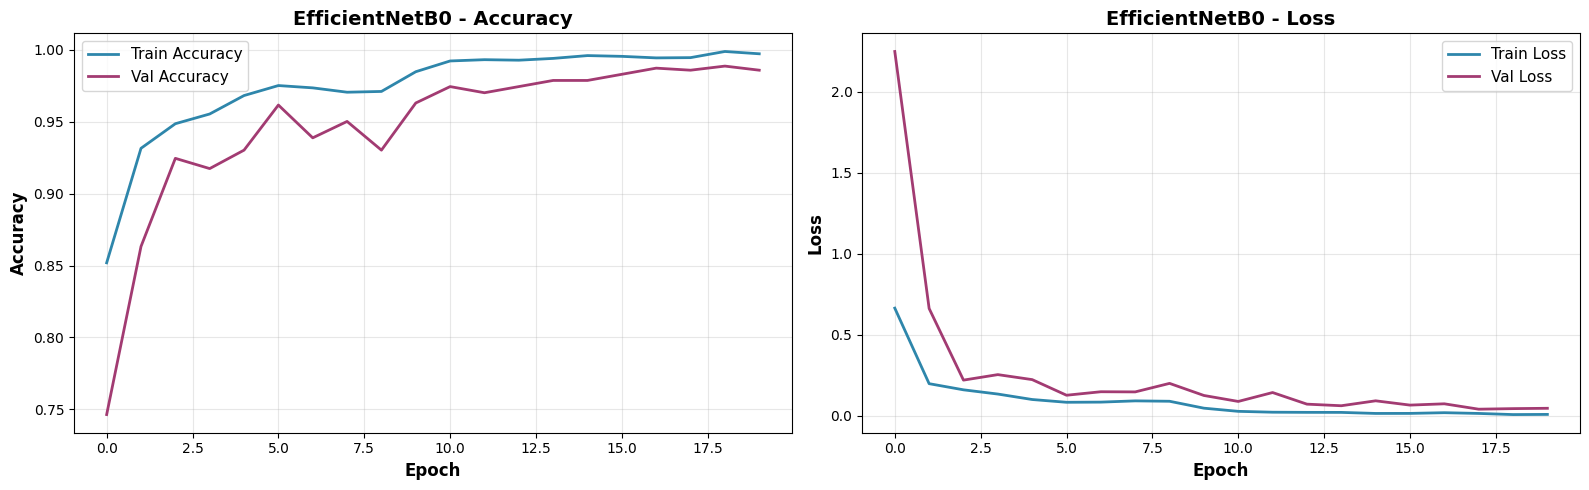

In [ ]:
def plot_training_history(history, model_name):
    """Plot training and validation metrics"""

    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    axes[0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2, color='#2E86AB')
    axes[0].plot(history.history['val_accuracy'], label='Val Accuracy', linewidth=2, color='#A23B72')
    axes[0].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[0].set_ylabel('Accuracy', fontsize=12, fontweight='bold')
    axes[0].set_title(f'{model_name} - Accuracy', fontsize=14, fontweight='bold')
    axes[0].legend(fontsize=11)
    axes[0].grid(True, alpha=0.3)

    axes[1].plot(history.history['loss'], label='Train Loss', linewidth=2, color='#2E86AB')
    axes[1].plot(history.history['val_loss'], label='Val Loss', linewidth=2, color='#A23B72')
    axes[1].set_xlabel('Epoch', fontsize=12, fontweight='bold')
    axes[1].set_ylabel('Loss', fontsize=12, fontweight='bold')
    axes[1].set_title(f'{model_name} - Loss', fontsize=14, fontweight='bold')
    axes[1].legend(fontsize=11)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

plot_training_history(history_eff, "EfficientNetB0")

In [ ]:
test_loss_eff, test_accuracy_eff = model_eff.evaluate(test_ds_eff, verbose=1)

print(f"  - Test Accuracy: {test_accuracy_eff*100:.2f}%")
print(f"  - Test Loss: {test_loss_eff:.4f}")

y_pred_eff = []
y_true_eff = []

for images, labels in test_ds_eff:
    preds = model_eff.predict(images, verbose=0)
    y_pred_eff.extend(np.argmax(preds, axis=1))
    y_true_eff.extend(labels.numpy())

y_pred_eff = np.array(y_pred_eff)
y_true_eff = np.array(y_true_eff)


22/22 ━━━━━━━━━━━━━━━━━━━━ 13s 605ms/step - accuracy: 0.9900 - loss: 0.0449
  - Test Accuracy: 99.00%
  - Test Loss: 0.0449


In [ ]:
model_eff.save("Brain Tumor_EfficientNetB0.h5")

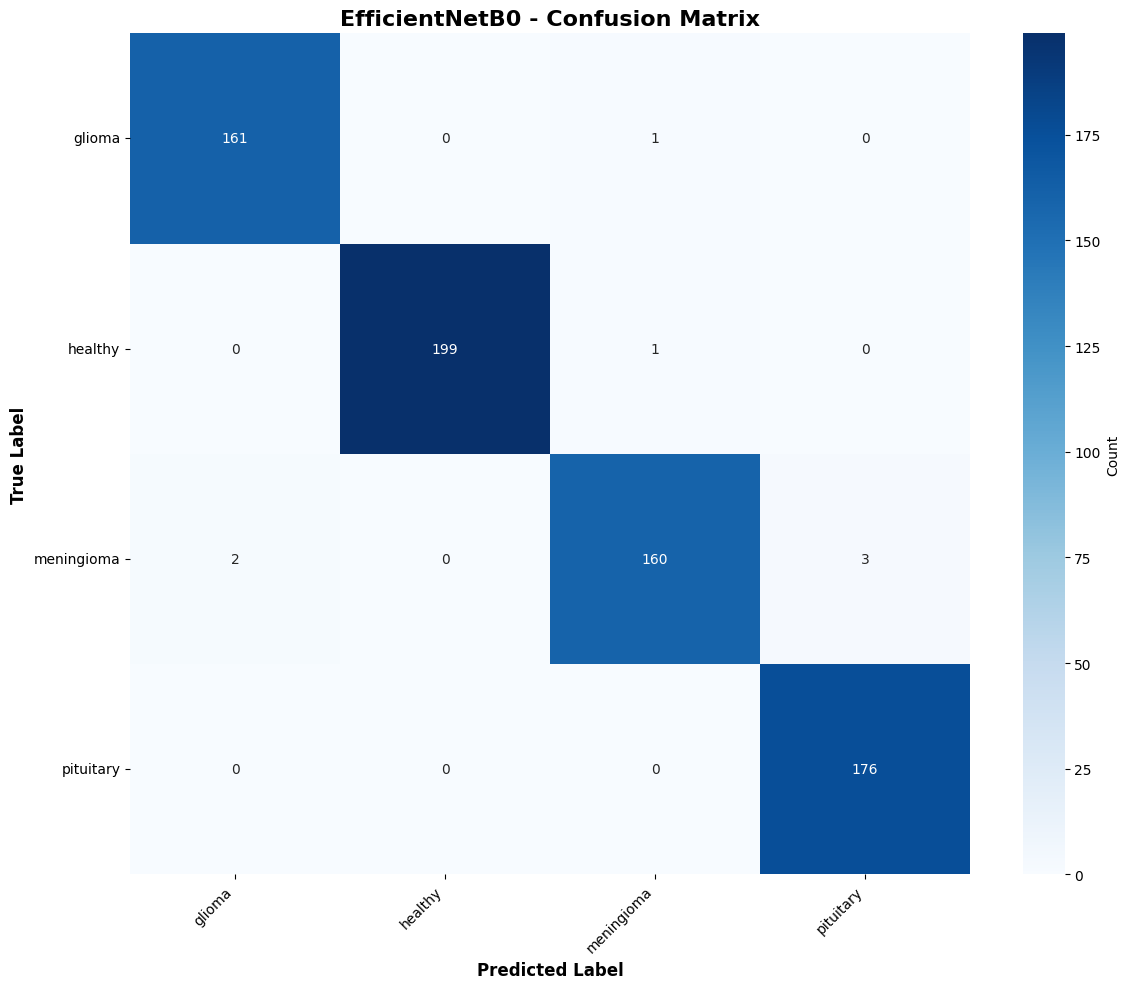

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

cm_eff = confusion_matrix(y_true_eff, y_pred_eff)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_eff, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names,
            cbar_kws={'label': 'Count'})
plt.title('EfficientNetB0 - Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('True Label', fontsize=12, fontweight='bold')
plt.xlabel('Predicted Label', fontsize=12, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
